# 2026-003 shRunt Redo CXCR6

In [1]:
# Load R Packages
library(fcexpr) # Reads FlowJo Workspace files
library(ggplot2)
library(cowplot)
library(ggpubr)
library(ggsci)
library(ggprism)
library(tidyr)
library(dplyr)


Attaching package: ‘ggpubr’


The following object is masked from ‘package:cowplot’:

    get_legend



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# Set Working Directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig03")

# Load flow processing functions
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Load exported table data from FlowJo (percent of parent, wide format:
# columns are File, Total, a, b, c, d)
percent.d6 <- read.csv("d6.cxcr6.csv", header = TRUE)
percent.d8 <- read.csv("d8.cxcr6.csv", header = TRUE)

# Load day 8 counts (needed to weight-average the two FCS files per mouse).
# First/last columns are blank in the source CSV (rowname + trailing comma);
# R names them X / X.1. Drop the trailing summary rows (Mean, SD).
count.d8 <- read.csv("d8.cxcr6.count.csv", header = TRUE) %>%
    rename(File = X) %>%
    select(-X.1) %>%
    filter(!File %in% c("Mean", "SD"))

# Load Key Files
key.d6 <- read.csv("D6P3_Key.csv")
key.d8 <- read.csv("D8P3_Key.csv")


Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘purrr’


The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice




## Process CXCR6 table data

`Total`, `a`, `b`, `c`, `d` are gate names from the FlowJo table export (all
percent-of-parent). `a`-`d` are children of `Total` in the gating tree, but
for this analysis they are treated as siblings (independent percentages, not
compounded through `Total`), so `PopulationFullPath` is left flat.

In [3]:
# Pivot a wide FlowJo table export (File, Total, a, b, c, d) to long format
# and join with the key to attach MouseID/Group.
# FileName is of the form export_[\d{6}]_CD8.fcs; only keep the number,
# which is the unique sample identifier shared with the key.
pivot_and_key <- function(df, key, day_label, value_name) {
    df %>%
        pivot_longer(cols = c(Total, a, b, c, d),
                      names_to = "Population", values_to = value_name) %>%
        mutate(
            FileName = str_remove(File, "^export_"),
            FileName = str_remove(FileName, "_CD8\\.fcs$")
        ) %>%
        left_join(
            key %>%
                mutate(NumericFilename = str_remove(NumericFilename, "\\.fcs$")) %>%
                select(NumericFilename, MouseID, Group),
            by = c("FileName" = "NumericFilename")
        ) %>%
        mutate(ID = MouseID, Day = day_label) %>%
        select(-MouseID)
}

surface.d6 <- pivot_and_key(percent.d6, key.d6, 6, "Percent") %>%
    select(ID, Group, Day, Population, Percent)

surface.d8 <- pivot_and_key(percent.d8, key.d8, 8, "Percent")
counts.d8  <- pivot_and_key(count.d8, key.d8, 8, "Count")

# Attach Count to the day 8 percent table (matched by FileName + Population,
# i.e. per individual FCS file, before combining the two files per mouse)
surface.d8 <- surface.d8 %>%
    left_join(
        counts.d8 %>% select(FileName, Population, Count),
        by = c("FileName", "Population")
    ) %>%
    select(ID, Group, Day, Population, Percent, Count)

head(surface.d6)
head(surface.d8)

ID,Group,Day,Population,Percent
<chr>,<chr>,<dbl>,<chr>,<dbl>
6A1,shCd19,6,Total,60.60
6A1,shCd19,6,a,9.38
6A1,shCd19,6,b,18.20
6A1,shCd19,6,c,11.80
6A1,shCd19,6,d,13.30
6A2,shCd19,6,Total,64.80


ID,Group,Day,Population,Percent,Count
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
8A1,shCd19,8,Total,66.00,22949
8A1,shCd19,8,a,2.16,752
8A1,shCd19,8,b,12.90,4483
8A1,shCd19,8,c,28.80,10009
8A1,shCd19,8,d,11.70,4051
8A1,shCd19,8,Total,66.70,23561


In [4]:
# Day 8 data is collected from 2 separate FCS files per mouse to expand event
# capture. Combine the two FCS files by weighted average of Percent,
# weighted by Count.
surface.d8_weighted <- surface.d8 %>%
    group_by(ID, Group, Day, Population) %>%
    summarise(
        Percent = weighted.mean(Percent, w = Count, na.rm = TRUE),
        Count   = sum(Count, na.rm = TRUE),
        .groups = "drop"
    )

head(surface.d8_weighted)

ID,Group,Day,Population,Percent,Count
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
8A1,shCd19,8,Total,66.354605,46510
8A1,shCd19,8,a,2.073352,1450
8A1,shCd19,8,b,12.849861,8991
8A1,shCd19,8,c,29.416951,20600
8A1,shCd19,8,d,11.501844,8028
8A2,shCd19,8,Total,68.758534,30555


In [5]:
# Combine the two days
surface <- bind_rows(surface.d6, surface.d8_weighted)
surface$Day <- factor(surface$Day, levels = c(6, 8))
surface$Group <- factor(surface$Group, levels = c("shCd19", "shRunx1", "shRunx2", "shRunx3", "shCbfb"))

# PopulationFullPath is flat (Total, a, b, c, d treated as siblings), so
# PercentOfTotal reduces to Percent for each -- computed here anyway to keep
# the output schema identical to 2026-003-shRuntRedo.ipynb
surface <- surface %>% rename(PopulationFullPath = Population)

total_percent <- compute_percent_of_total(surface) %>%
    add_population_derivatives() %>%
    finalize_flow_table(round_digits = NULL)

head(total_percent, n = 20)

# Export to CSV
write.csv(total_percent, "2026-003-Cxcr6.csv", row.names = FALSE, quote = FALSE)

ID,Group,Population,Day,Count,Percent,PercentOfTotal
<chr>,<fct>,<chr>,<fct>,<dbl>,<dbl>,<dbl>
6A1,shCd19,Total,6,NA,60.60,60.60
6A1,shCd19,a,6,NA,9.38,9.38
6A1,shCd19,b,6,NA,18.20,18.20
6A1,shCd19,c,6,NA,11.80,11.80
6A1,shCd19,d,6,NA,13.30,13.30
6A2,shCd19,Total,6,NA,64.80,64.80
6A2,shCd19,a,6,NA,9.74,9.74
6A2,shCd19,b,6,NA,25.20,25.20
6A2,shCd19,c,6,NA,11.00,11.00


## Plot

In [6]:
# Create a default theme
colors <- c(
    "shCd19"    = "#808180",
    "shRunx1"   = "#96A648",
    "shRunx2"   = "#FAC85C",
    "shRunx3"   = "#DC0000",
    "shCbfb"    = "#557D6E"
)

# Use ggprism, base 12, not bold, and remove legend
theme <- theme_bw(     base_size = 14,
                        base_family = "sans",
                        #base_fontface = "plain"
                        ) +
    theme(  axis.text = element_text(size = 10),
            axis.title = element_text(size = 12),
            axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 12),
            axis.title.x = element_blank(),            strip.text = element_text(size = 12),
            legend.position = "none",
            plot.title = element_text(size = 12),  # Set main title size
            panel.grid = element_blank())  # Remove gridlines

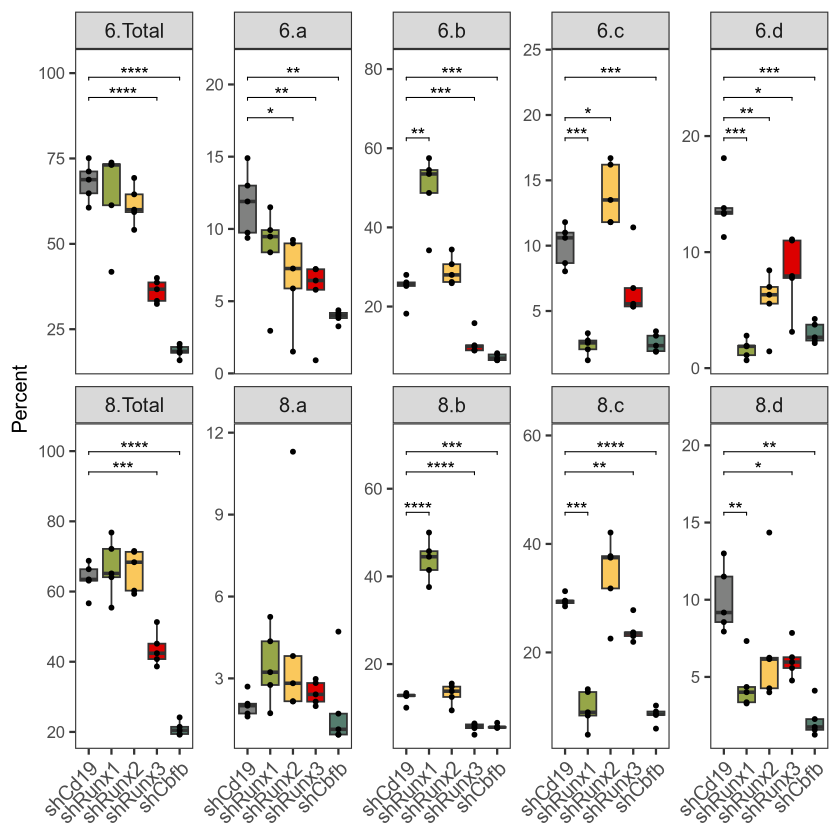

In [7]:
# Facet by Day (rows: 6 top, 8 bottom) and Population (cols: Total, a, b, c, d)
plot.data.df <- total_percent %>%
    mutate(Population = factor(Population, levels = c("Total", "a", "b", "c", "d"))) %>%
    mutate(facet = interaction(Day, Population, lex.order = TRUE)) %>%
    arrange(facet, ID)

# Compare every group back to shCd19
comparisons <- list(
    c("shCd19", "shRunx1"),
    c("shCd19", "shRunx2"),
    c("shCd19", "shRunx3"),
    c("shCd19", "shCbfb")
)

# Calculate p-values and BH-adjusted p-values for shCd19 vs. each other group
plot.stat.df <- plot_padj(
    data = plot.data.df,
    comparisons = comparisons,
    y_col = "Percent",
    x_col = "Group",
    facet_col = "facet",
    step_fraction = 0.1,
    min_step = 0.5
)

# Save comparison statistics (p, p.adj, fold changes) to CSV
write.csv(plot.stat.df, "2026-003-Cxcr6_stats.csv", row.names = FALSE)

# Only the significant comparisons get a bracket drawn (see
# stat_pvalue_manual below), so only these need extra headroom
plot.stat.sig <- plot.stat.df %>% filter(p.adj < 0.05)

# Create the plot
p <- ggplot(plot.data.df, aes(x = Group, y = Percent, fill = Group)) +
    geom_boxplot(outlier.shape = NA) +
    geom_point(size = 1) +
    facet_wrap(~ facet, ncol = 5, scales = "free_y") +
    theme +
    scale_fill_manual(values = colors) +
    # Make room for the p-value bracket: with scales = "free_y", each panel
    # auto-scales to plot.data.df alone, so the bracket drawn at y.position
    # (above the tallest box, per plot_padj()'s step_fraction/min_step) would
    # get clipped at the top of the panel without this. geom_blank() is
    # invisible but still trains the y-scale, and a small multiplier adds
    # headroom for the label text sitting above the bracket line itself.
    geom_blank( data = plot.stat.sig, aes(x = group1, y = y.position),
                inherit.aes = FALSE) +
    scale_y_continuous(expand = expansion(mult = c(0.05, 0.10))) +
    stat_pvalue_manual(
        plot.stat.sig,
        label = "p.adj.signif",   # adjusted p-value stars
        tip.length = 0.01,
        size = 4,
        inherit.aes = FALSE       # important fix
    )

print(p)

In [9]:
pdf(file =  paste0("2026-003-Fig03_", "Cxcr6", ".pdf"), width = 6.5, height = 3)

p   <- p + 
    theme(  axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 1),
            strip.text = element_blank(),
            strip.background = element_blank()) +
    scale_x_discrete(labels = c(
        "shCd19"    = "a",
        "shRunx1"   = "b",
        "shRunx2"   = "c",
        "shRunx3"   = "d",
        "shCbfb"    = "e"
    ))

print(p)

dev.off()

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


pdf 
  2